NHAN BUI

### Lab - Machine Learning
In this notebook, you will use the Gaussian Naive Bayes estimator to perform and evaluate a binary classification.  You will also compare the performance of this algorithm to other classification algoritms.

This is the Breast Cancer Wisconsin Diagnostic dataset that is bundled with scikit-learn

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html#sklearn.datasets.load_breast_cancer

The dataset contains 569 samples, each with 30 features and a label indicating whether a tumor was malignant (0) or benign (1). There are only two labels, so this dataset is commonly used to perform binary classification. 

Using this dataset, reimplement the steps of this chapter’s classification case study in Sections 15.2–15.3.
* Use the GaussianNB (short for Gaussian Naive Bayes) estimator. 
* When you execute multiple classifiers (as in Section 15.3.3) to determine which one is best for the Breast Cancer Wisconsin Diagnostic dataset, include a LogisticRegression classifier in the estimators dictionary.
  

**Implement the following steps/tasks. Clearly document each step with markup descriptions. (HINT: look at the steps in the book from 15.2.2-15.3.3)**
* Load the data
* Display the data description
* Check the sample and target sizes
* Split the data for training and testing
* Create the model (GaussianNB)
* Train the model
* Predict
* Determine accuracy with score
* Determine accuracy with confusion matrix.  
* Visualize the confusion matrix using a heat map
* Determine accuracy with classification report
* Perform k-fold cross validation
* Run multiple models using a dictionary of esitmators and a for loop to find the best one, include GaussianNB, KNeighborsClassifier, LogisticRegression, and SVC.
* Which classifer performs the best?







# Step 1 
I import the necessary Python libraries and load the Breast Cancer 
- data.data the 30 numeric features for each sample
- data.target the classification labels (0 = malignant, 1 = benign)
- data.feature_name the names of each feature column
I store the feature values in X, the target values in y, and then create a pandas DataFrame to view the dataset like a spreadsheet.  



In [3]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np

# load the dataset
data = load_breast_cancer()

# Feature matrix (X) and target vector (y)
X = data.data          # the 30 numeric features
y = data.target        # 0 = malignant, 1 = benign


df = pd.DataFrame(X, columns=data.feature_names) #for columns names, excel tabel
df['target'] = y  # add column name target to the filter data.target

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# Step 2 
Here I print part of the dataset description using `data.DESCR`.  
- What the dataset represents
- How many samples and features it has
- What the target classes mean (malignant vs benign)
slice the string with [:1500] so that only the first 1500 characters are shown


In [4]:
print(data.DESCR[:1500]) #describes the dataset with the first 1500 character


.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

# Step 3

In this step, I check the dimensions of the feature matrix `X` and the target vector `y`.
- `X.shape` shows how many samples and features are in the dataset.
- `y.shape` shows how many target values (labels) there are.
- `data.target_names` displays the names of the classes.



In [5]:
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Target names:", data.target_names)


Feature matrix shape: (569, 30)
Target vector shape: (569,)
Target names: ['malignant' 'benign']


# Step 4
In this step, divide the dataset into two parts so the model is trained and tested
I use train_test_split to separate **75% of the data to training** and **25% to testing**.
- `X_train` and `y_train` will be used to train the classifier.
- `X_test` and `y_test` will be used to evaluate performance on unseen data.
- `stratify=y` ensures both sets keep the same malignant/benign ratio.
- `random_state=11` guarantees the split is reproducible every time the notebook runs.
After splitting, I check the shapes of the training and testing sets to confirm the division was successful.


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25, #25% of the data for testing, 75% left for training.
    random_state=11,#same w random.seed
)

X_train.shape, X_test.shape


((426, 30), (143, 30))

## Step 5 – Create the Gaussian Naive Bayes Model

In this step, I create the machine learning model that will be used to classify the tumors as malignant or benign. I import the `GaussianNB` class from `sklearn.naive_bayes`, which implements the Gaussian Naive Bayes algorithm.

Naive Bayes is a probabilistic classifier that:
- assumes the features are conditionally independent given the class, and  
- models each feature using a Gaussian (normal) distribution.

I then create an instance of this classifier and store it in the variable `model`. This object will be trained on the training data in the next step.


In [10]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model


GaussianNB()

# Step 6 
 
I call `model.fit(X_train, y_train)`, which allows the algorithm to learn the relationships between the input features and the target labels (malignant or benign).  

For Naive Bayes, this involves calculating the mean, variance, and prior probability for each class based on the training data.  
After running this step, the model has learned from the data and is ready to make predictions on the test set.


In [11]:
model.fit(X_train, y_train)


GaussianNB()

# Step 7 – Make Predictions

In this step, I use the trained Naive Bayes model to make predictions on the test dataset.  
I call `model.predict(X_test)` to create `y_pred`, which contains the model's predicted class labels (0 = malignant, 1 = benign) for each sample in the test set.  


In [13]:
y_pred = model.predict(X_test) #model trained to guess the class (0 or 1) for each row in X_test.
y_pred[:10]  #slicing the first 10 only predicted labels.


array([0, 0, 0, 0, 0, 1, 0, 1, 1, 1])

# Step 8 – Determine Accuracy with `.score()`

In this stepusing the `.score()` method.  
This calculates the model's accuracy, which is the proportion of correctly classified samples in the test set.

`model.score(X_test, y_test)` internally compares the model's predictions with the true labels and returns a value between 0 and 1 and how much % is correct



In [14]:
accuracy = model.score(X_test, y_test) # compare the model.predict x_test as predicted labels to the y_test
accuracy


0.951048951048951

## Step 9 – Confusion Matrix

In this step, I calculate the confusion matrix to evaluate the model's performance in more detail.  
The confusion matrix is a 2×2 table that compares the model's predicted labels (`y_pred`) with the true labels (`y_test`).
The four values in the confusion matrix represent:
- **True Negatives (TN):** malignant tumors correctly predicted as malignant  
- **False Positives (FP):** benign tumors incorrectly predicted as malignant  
- **False Negatives (FN):** malignant tumors incorrectly predicted as benign  
- **True Positives (TP):** benign tumors correctly predicted as benign  
This matrix allows me to see exactly how many samples were classified correctly and where the model made mistakes.


TN (Top-Left): True Negatives
malignant predicted malignant (correct)

FP (Top-Right): False Positives
benign predicted malignant (wrong)

FN (Bottom-Left): False Negatives
malignant predicted benign (wrong)

TP (Bottom-Right): True Positives
benign predicted benign (correct)

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred) # y_test = the true labels (actual answers: malignant or benign)
# y_pred = the predicted labels (what the model guessed)
# confusion_matrix() compares them and counts outcomes.
print(cm)


[[44  6]
 [ 1 92]]


## Step 10 – Visualize the Confusion Matrix

To better understand the model's performance, display the confusion matrix as a heat map using `ConfusionMatrixDisplay`.  
This visual representation makes it easier to see the number of true positives, true negatives, false positives, and false negatives.  
|
The x-axis represents predicted labels, and the y-axis represents true labels.  
This plot provides a clear picture of how well the model distinguishes between malignant and benign tumors.


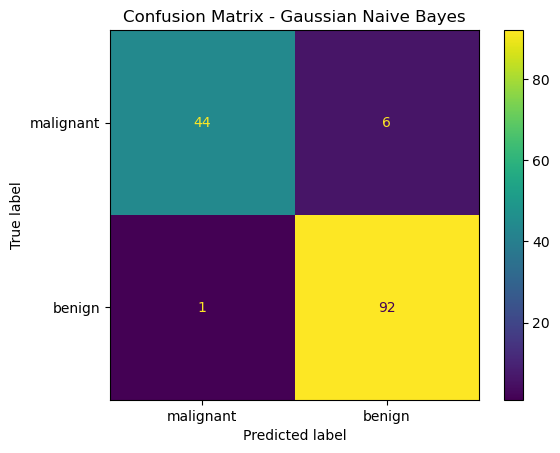

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay #display class that can draw the confusion matrix as a plot.
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names) # cm is confusion matrix
#displayy labels is "malignant", "benign"
disp.plot()
plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.show()


# Step 11 – Classification Report

In this step, I generate a detailed classification report using the `classification_report()` function from scikit-learn. 
- **Precision:** Out of all the samples predicted belong to a class, show how many is corrected
- **Recall:** Out of all the actual samples for a class, how many did the model correctly identify?
- **F1-score:** The harmonic mean of precision and recall, giving a balanced measure of performance.
- **Support:** The number of true samples belonging to each class in the dataset.

understand how accurate the model is overall, also where it performs well or poorly for malignant versus benign tumors.


In [24]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, target_names=data.target_names) #true labels and predicted labels
#target_names=data.target_names displays "malignant" and "benign"
print(report)


              precision    recall  f1-score   support

   malignant       0.98      0.88      0.93        50
      benign       0.94      0.99      0.96        93

    accuracy                           0.95       143
   macro avg       0.96      0.93      0.94       143
weighted avg       0.95      0.95      0.95       143



# Step 12 – Perform 10-Fold Cross Validation
In this step,use 10-fold cross validation to evaluate the Gaussian Naive Bayes classifier more  
Instead of relying on just one train/test split, I use `cross_val_score()` to split the entire dataset into 10 folds:
- For each run, the model is trained on 9 folds and tested on the remaining fold.
- This process repeats 10 times so every fold is used as a test set once.
I create a fresh `GaussianNB` model (unfitted) so that cross validation can train it from scratch on each split.  



In [25]:
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB 

# create a fresh gauss model for cross-validation
gnb = GaussianNB()#need a clean model

cv_scores = cross_val_score(gnb, X, y, cv=10) #train for 10 fold
print("Cross-validation scores for each fold:", cv_scores)
print("Mean accuracy:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())


Cross-validation scores for each fold: [0.94736842 0.87719298 0.89473684 0.92982456 0.94736842 0.96491228
 0.92982456 0.96491228 0.94736842 0.96428571]
Mean accuracy: 0.9367794486215537
Standard deviation: 0.02844425208918023


# Step 13 – Compare Multiple Classifiers with 10-Fold Cross Validation

In this step, I compare the performance of several different classification algorithms on the same breast cancer dataset:
- Gaussian Naive Bayes (`GaussianNB`)
- k-Nearest Neighbors (`KNeighborsClassifier`)
- Logistic Regression (`LogisticRegression`)
- Support Vector Classifier (`SVC`)
I store these models in a dictionary and use a `for` loop to run 10-fold cross validation on each one using `cross_val_score()`.  
For each classifier, I compute the mean accuracy and standard deviation across the 10 folds.

Finally, I determine which classifier performed the best by selecting the model with the highest mean accuracy


In [27]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

# dictionary of models to compare
estimators = { #give key to value 
    "GaussianNB": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "LogisticRegression": LogisticRegression(max_iter=10000),
    "SVC": SVC()
}

results = {}

# run 10-fold cross validation for each model
for name, model in estimators.items():
    scores = cross_val_score(model, X, y, cv=10)
    results[name] = scores.mean()
    print(f"{name} - Mean Accuracy: {scores.mean():.4f}  (Std: {scores.std():.4f})")
#shows each model’s mean accuracy and standard deviation
# determine the best model
best_model = max(results, key=results.get) # finds the key (model name) with the highest mean accuracy.
print("\nBest performing classifier:", best_model)
print("Best mean accuracy:", results[best_model])


GaussianNB - Mean Accuracy: 0.9368  (Std: 0.0284)
KNN - Mean Accuracy: 0.9298  (Std: 0.0293)
LogisticRegression - Mean Accuracy: 0.9543  (Std: 0.0238)
SVC - Mean Accuracy: 0.9139  (Std: 0.0288)

Best performing classifier: LogisticRegression
Best mean accuracy: 0.9543233082706767
